<a href="https://colab.research.google.com/github/RenteriaRaul/Doctorado-DCAG/blob/main/notebooks/sustax/06_sustax_flood_detection_proxy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Configuración**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
import os
import pandas as pd
from IPython.display import Image, display

PROJECT_PATH = "/content/drive/MyDrive/Doctorado-DCAG"
os.chdir(PROJECT_PATH)
sys.path.append(PROJECT_PATH)

print("Working directory:", os.getcwd())

Mounted at /content/drive
Working directory: /content/drive/MyDrive/Doctorado-DCAG


# **Imports**

In [2]:
from scripts.sustax.flood_proxy import (
    detect_future_extreme_events,
    export_future_events,
    build_summary_by_scenario_and_type,
    plot_heatmap_by_scenario,
    plot_heatmap_by_event_type,
    plot_station_counts,
    plot_month_distribution,
)

# **Configuración**

In [3]:
PROJECT_DIR = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación"
SUSTAX_DIR = os.path.join(PROJECT_DIR, "Datos Sustax")

BYSCEN_TOTAL_FOLDER = os.path.join(SUSTAX_DIR, "SUSTAX_TOTAL_MERGED", "BY_SCENARIO_TOTAL")
OUT_DIR = os.path.join(SUSTAX_DIR, "FLOOD_DETECTION_PROXY")
os.makedirs(OUT_DIR, exist_ok=True)

OUT_CSV = os.path.join(OUT_DIR, "future_extreme_events_2027_2040.csv")

YEAR_START = 2027
YEAR_END = 2040

POINTS_TO_USE = [
    "Sustax_ Manzanillo_LosReyesTotal",
    "Sustax_ManzanilloTotal",
    "Sustax_MinatitlanTotal",
    "Sustax_TecomanTotal",
    "Sustax_TolimanTotal",
    "Sustax_Veladero_de_OtatesTotal",
    "Sustax_VilladeAlvarezTotal",
    "Sustax_Zapotitlan_de_VadilloTotal",
]

SSP_LIST = ["SSP119", "SSP126", "SSP245", "SSP370", "SSP434", "SSP460", "SSP585"]

print("BYSCEN_TOTAL_FOLDER:", BYSCEN_TOTAL_FOLDER)
print("OUT_DIR:", OUT_DIR)

BYSCEN_TOTAL_FOLDER: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/SUSTAX_TOTAL_MERGED/BY_SCENARIO_TOTAL
OUT_DIR: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/FLOOD_DETECTION_PROXY


# **Detección de eventos**

In [4]:

df_future_events = detect_future_extreme_events(
    byscen_total_folder=BYSCEN_TOTAL_FOLDER,
    points_to_use=POINTS_TO_USE,
    ssp_list=SSP_LIST,
    year_start=YEAR_START,
    year_end=YEAR_END,
)

display(df_future_events.head(30))

export_future_events(df_future_events, OUT_CSV)

print("Archivo guardado en:")
print(OUT_CSV)

summary = build_summary_by_scenario_and_type(df_future_events)
display(summary.head(20))

,point,scenario,date,year,month,event_type,value_mm,threshold_mm
0,Sustax_Zapotitlan_de_VadilloTotal,SSP119,2027-02-23,2027,2,daily_extreme,34.332078,26.984014
1,Sustax_MinatitlanTotal,SSP119,2027-09-03,2027,9,daily_extreme,38.258906,32.043510
2,Sustax_Veladero_de_OtatesTotal,SSP119,2027-09-03,2027,9,daily_extreme,44.746693,39.782445
3,Sustax_VilladeAlvarezTotal,SSP119,2027-09-03,2027,9,daily_extreme,43.792121,31.190394
4,Sustax_TecomanTotal,SSP119,2027-09-04,2027,9,daily_extreme,35.309065,33.180650
5,Sustax_TolimanTotal,SSP119,2027-09-08,2027,9,daily_extreme,27.102837,25.722478
6,Sustax_Zapotitlan_de_VadilloTotal,SSP119,2027-09-08,2027,9,daily_extreme,29.469665,26.984014
7,Sustax_TolimanTotal,SSP119,2027-09-09,2027,9,daily_extreme,33.134826,25.722478
8,Sustax_ Manzanillo_LosReyesTotal,SSP119,2027-09-18,2027,9,daily_extreme,64.958230,39.259066
9,Sustax_ManzanilloTotal,SSP119,2027-09-18,2027,9,daily_extreme,66.020347,38.396374


Archivo guardado en:
/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/FLOOD_DETECTION_PROXY/future_extreme_events_2027_2040.csv


,scenario,event_type,n_events
18,SSP585,daily_extreme,660
3,SSP126,daily_extreme,572
9,SSP370,daily_extreme,533
6,SSP245,daily_extreme,509
0,SSP119,daily_extreme,483
12,SSP434,daily_extreme,446
15,SSP460,daily_extreme,390
13,SSP434,monthly_extreme,16
4,SSP126,monthly_extreme,6
10,SSP370,monthly_extreme,6


# **Generar figuras**




In [5]:
fig_scenario = os.path.join(OUT_DIR, "heatmap_events_by_scenario.png")
fig_type = os.path.join(OUT_DIR, "heatmap_events_by_type.png")
fig_station = os.path.join(OUT_DIR, "events_by_station.png")
fig_month = os.path.join(OUT_DIR, "events_by_month.png")

plot_heatmap_by_scenario(df_future_events, fig_scenario)
plot_heatmap_by_event_type(df_future_events, fig_type)
plot_station_counts(df_future_events, fig_station)
plot_month_distribution(df_future_events, fig_month)

print("Figuras generadas:")
print(fig_scenario)
print(fig_type)
print(fig_station)
print(fig_month)

Figuras generadas:
/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/FLOOD_DETECTION_PROXY/heatmap_events_by_scenario.png
/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/FLOOD_DETECTION_PROXY/heatmap_events_by_type.png
/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/FLOOD_DETECTION_PROXY/events_by_station.png
/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/FLOOD_DETECTION_PROXY/events_by_month.png


# **Mostrar imágenes clave**


Figura: heatmap_events_by_scenario.png
Existe: True


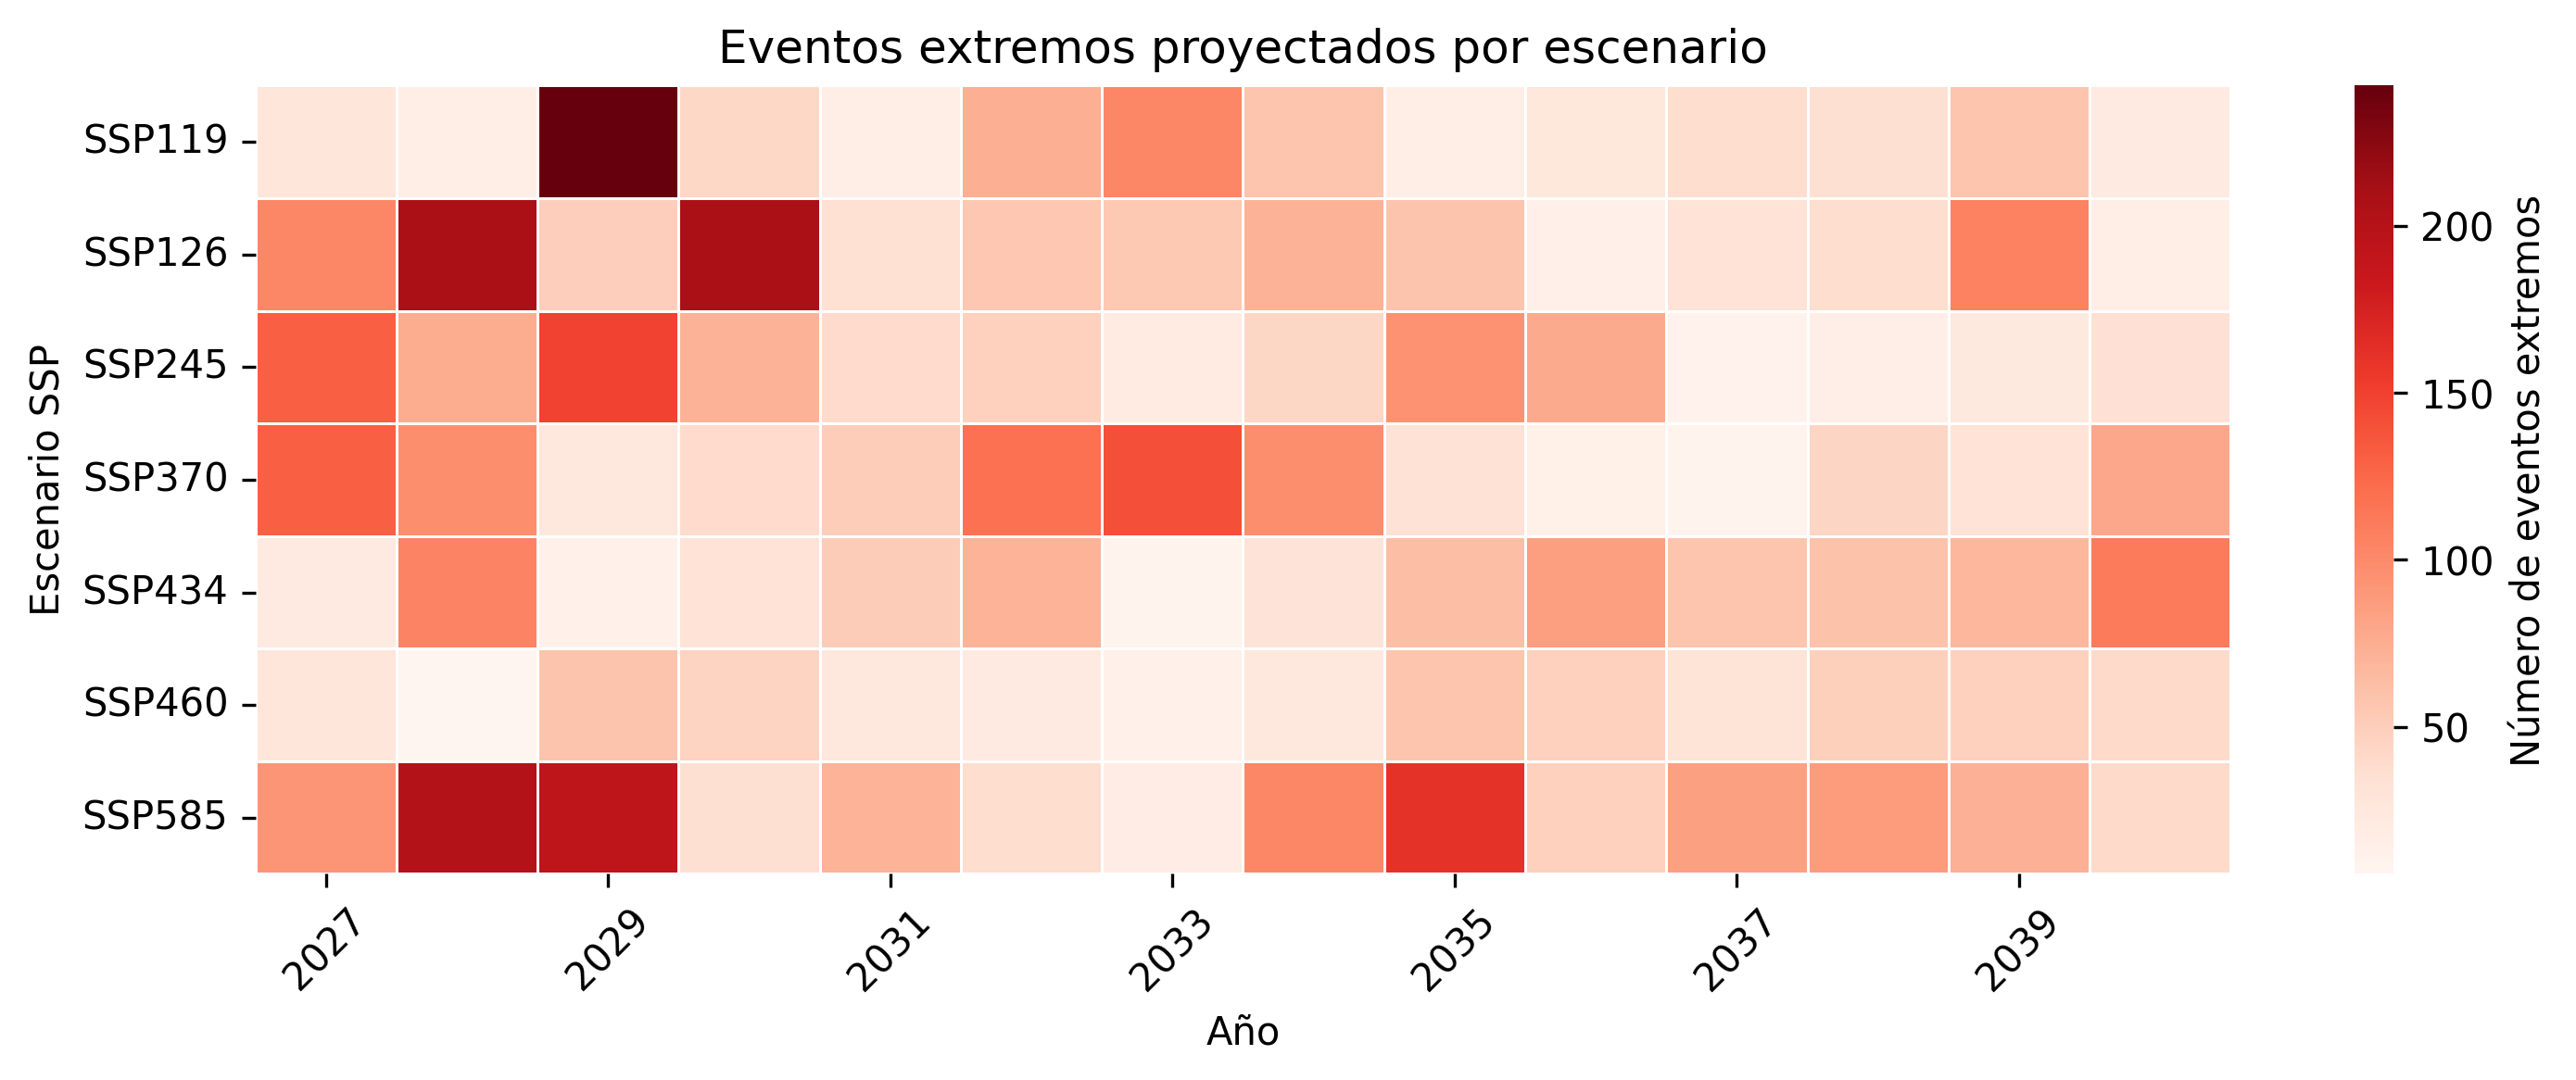


Figura: heatmap_events_by_type.png
Existe: True


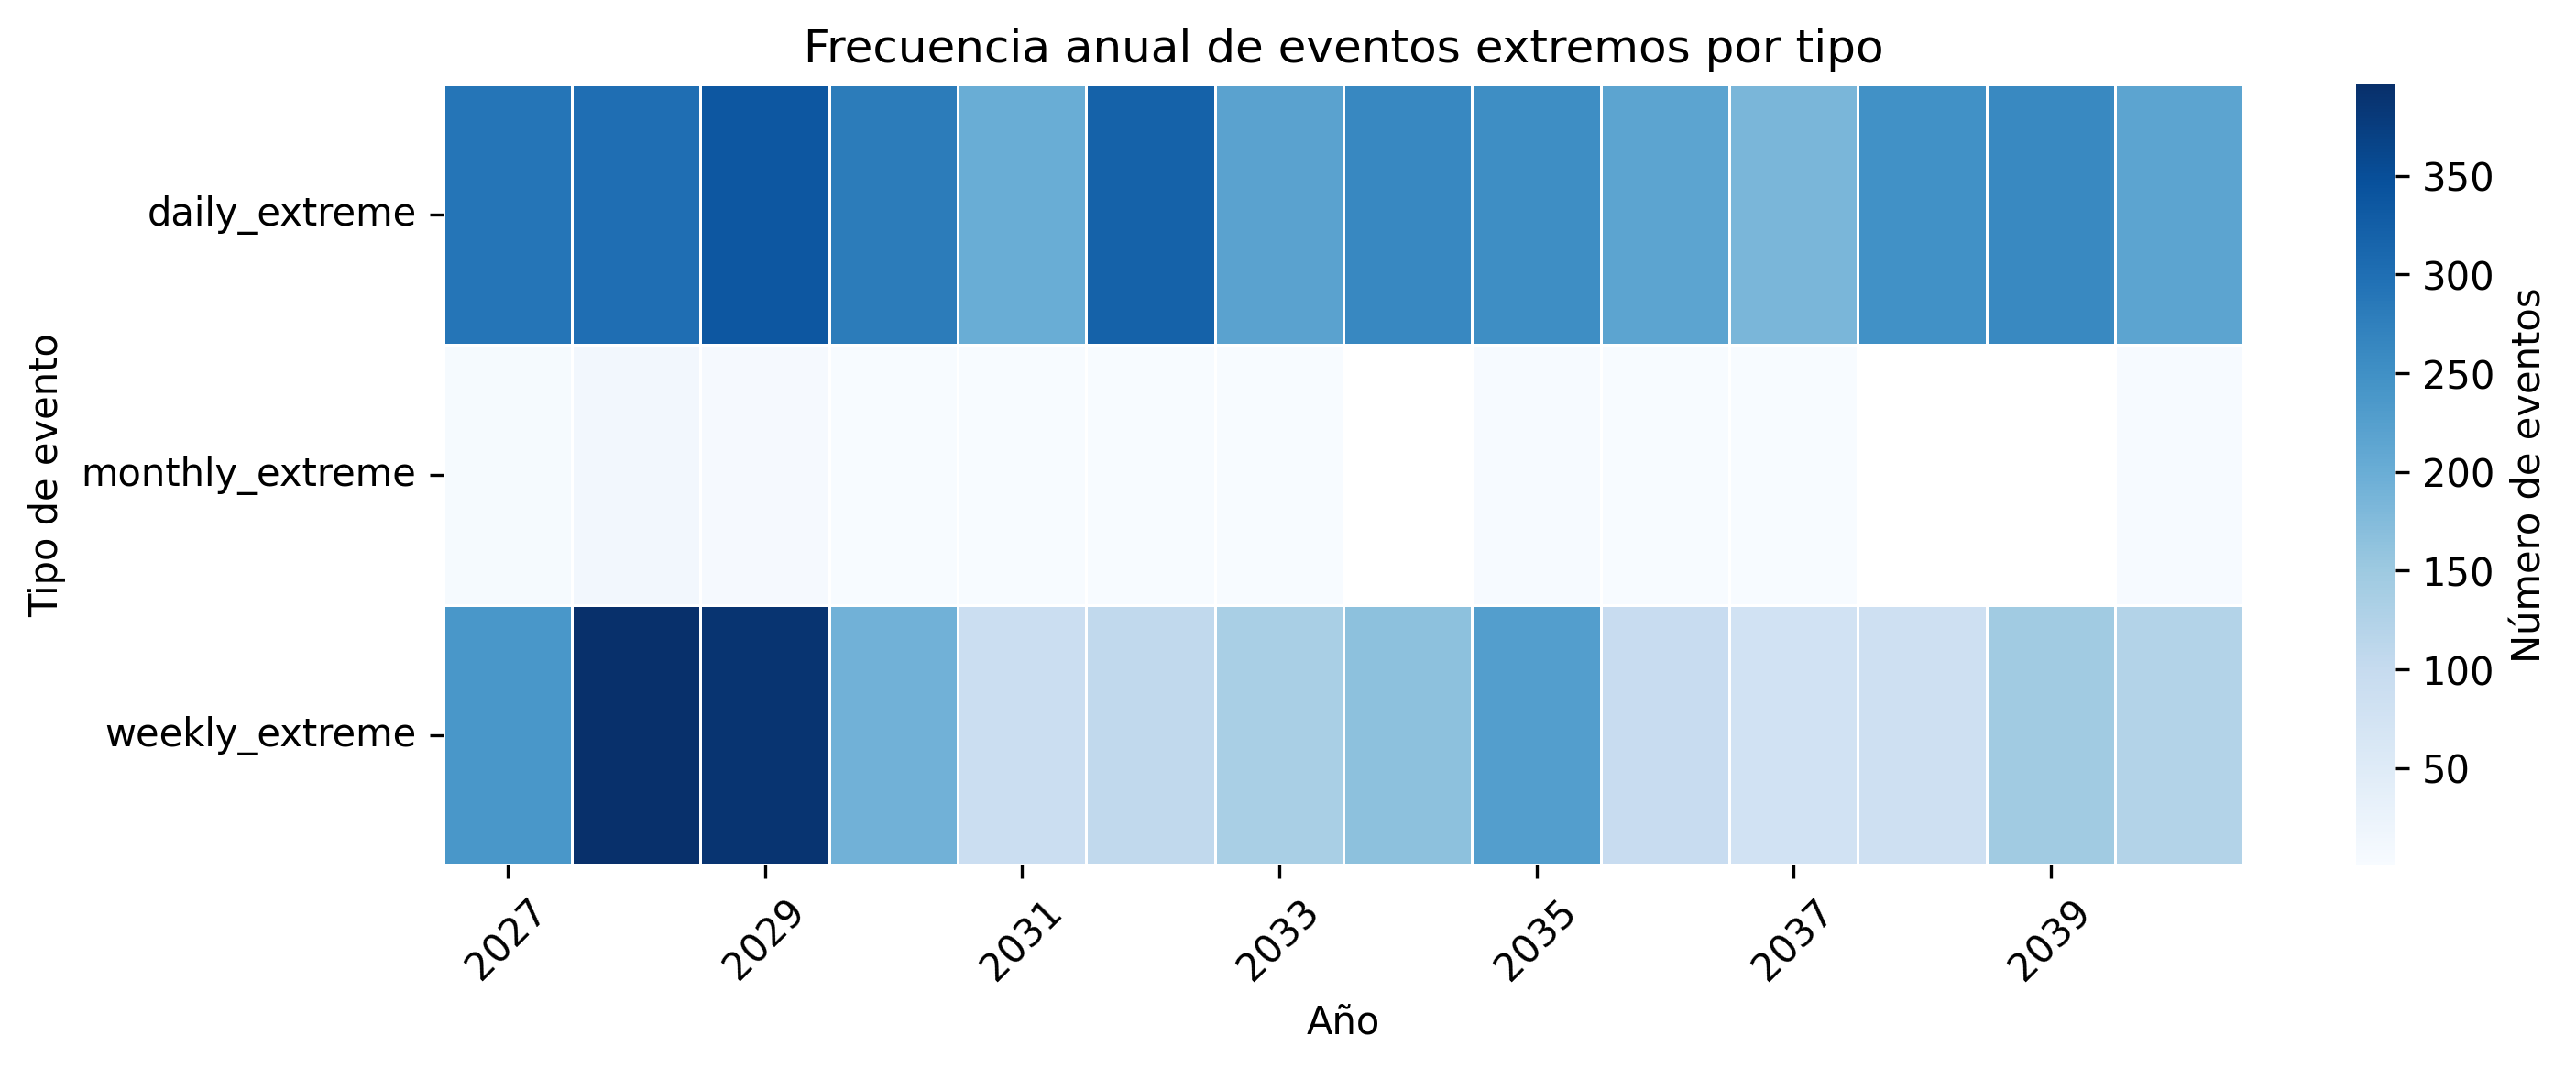


Figura: events_by_station.png
Existe: True


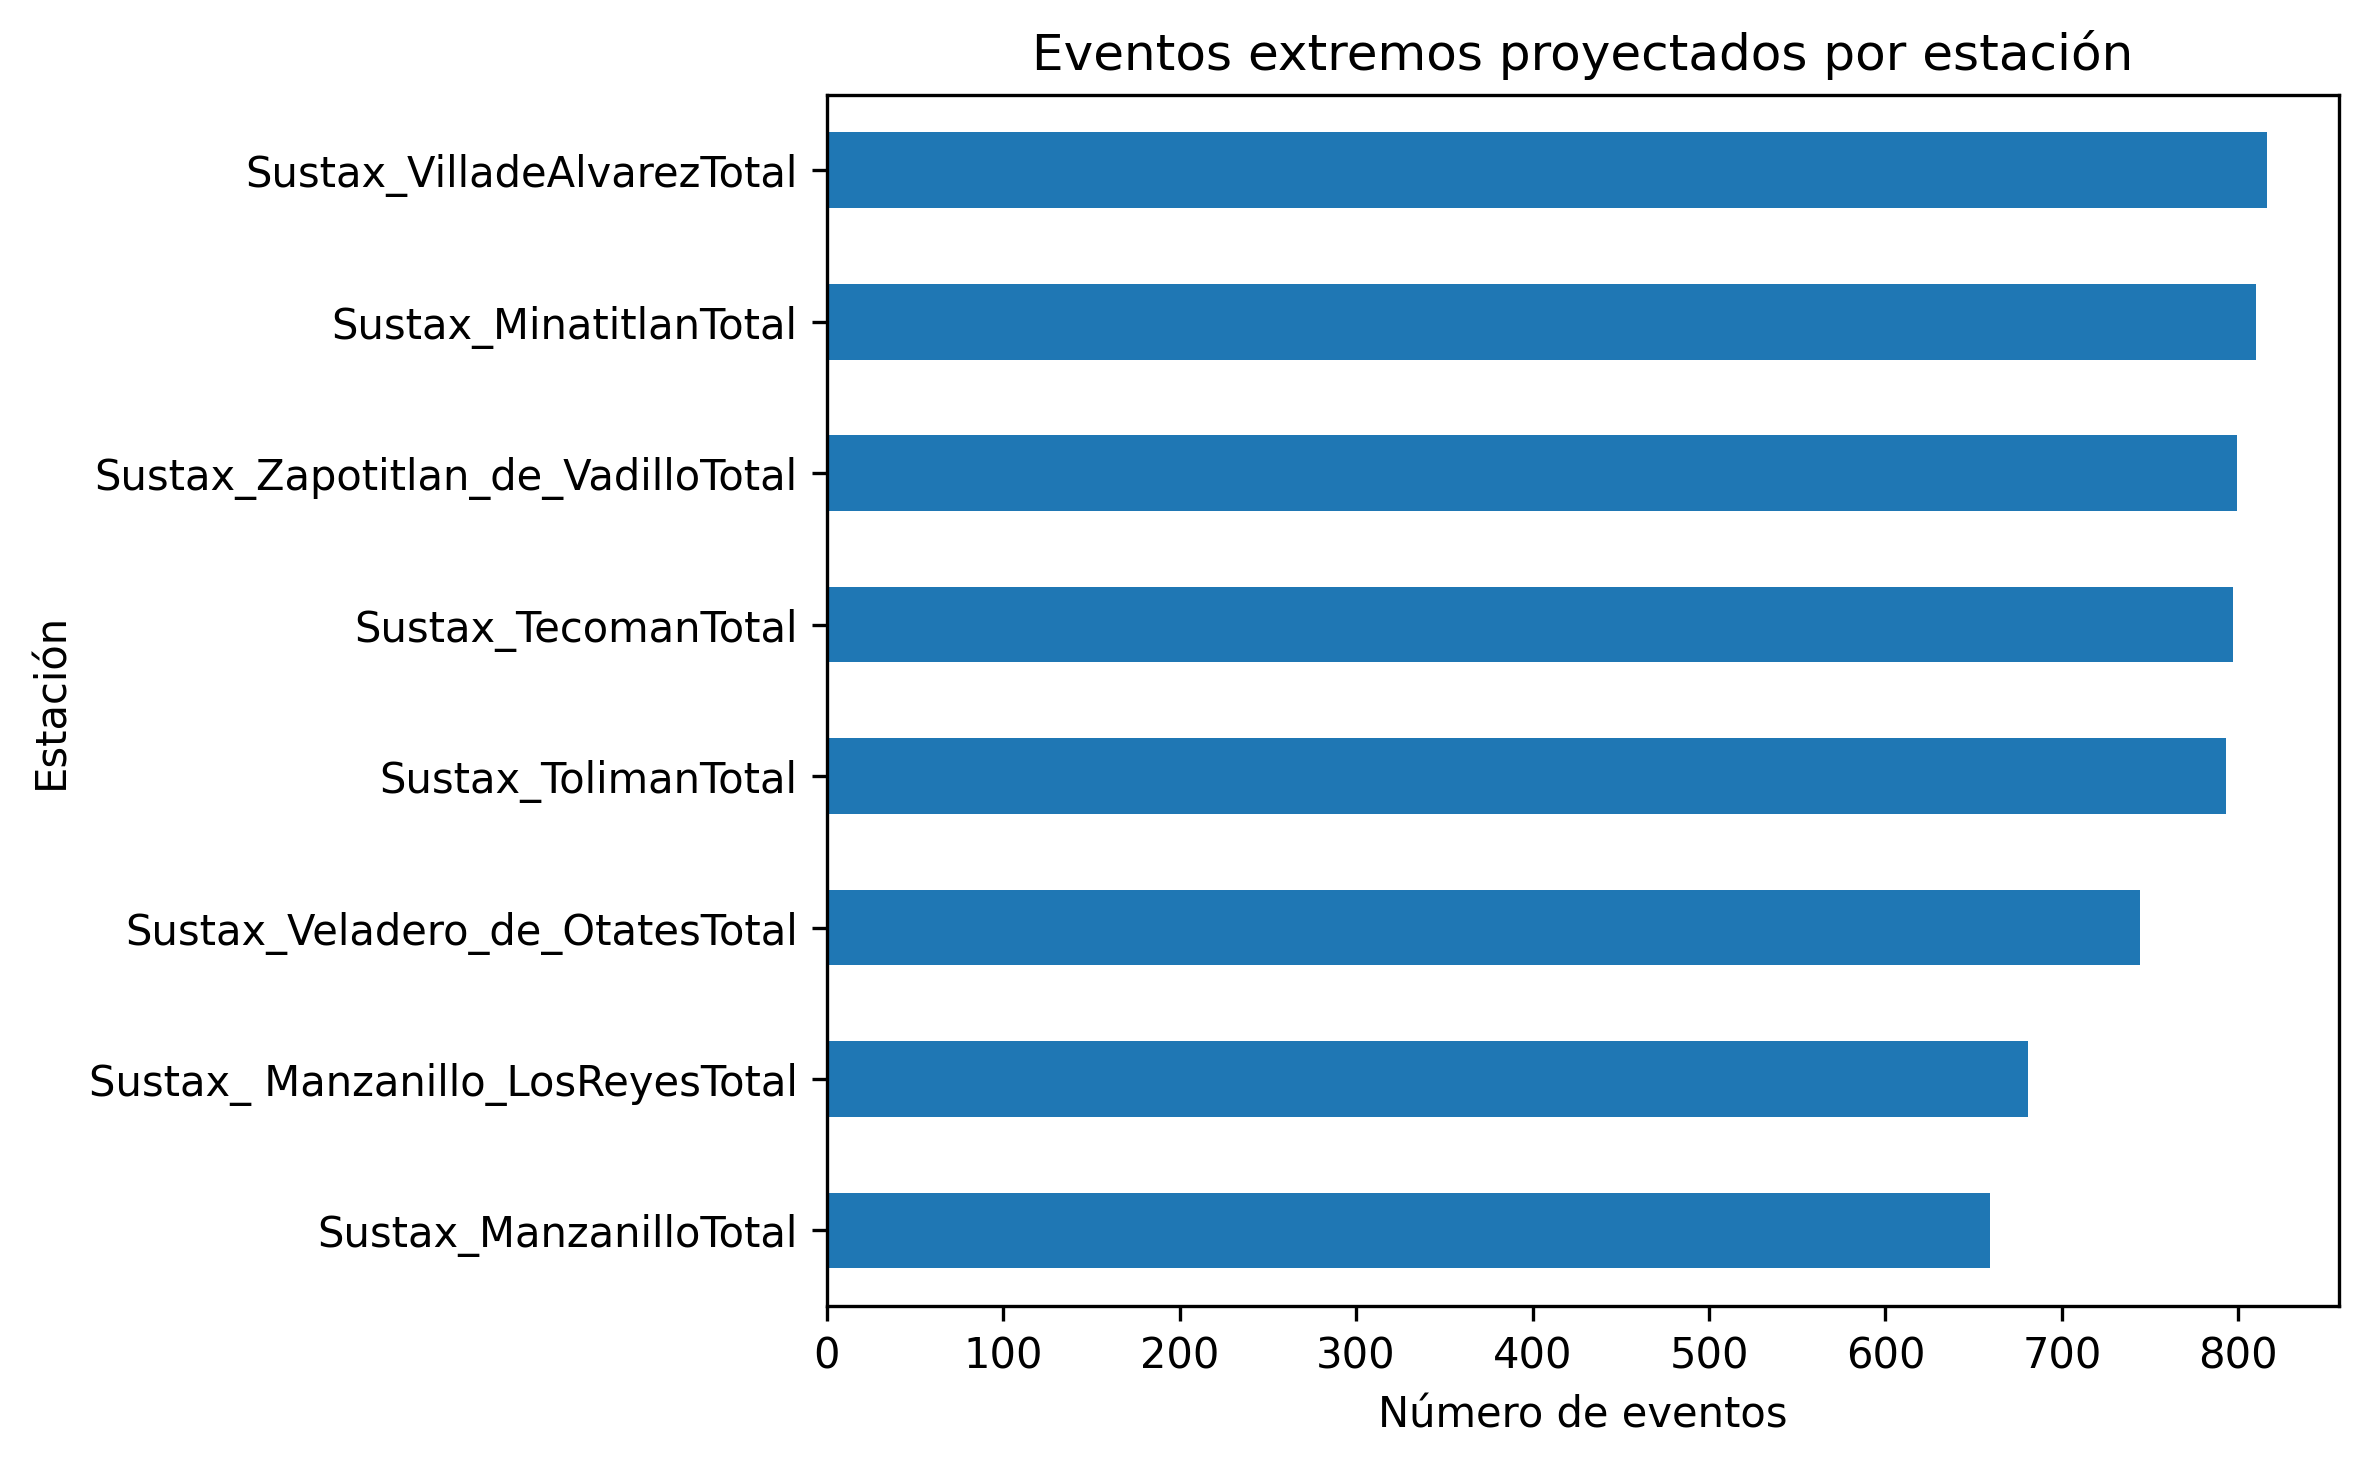


Figura: events_by_month.png
Existe: True


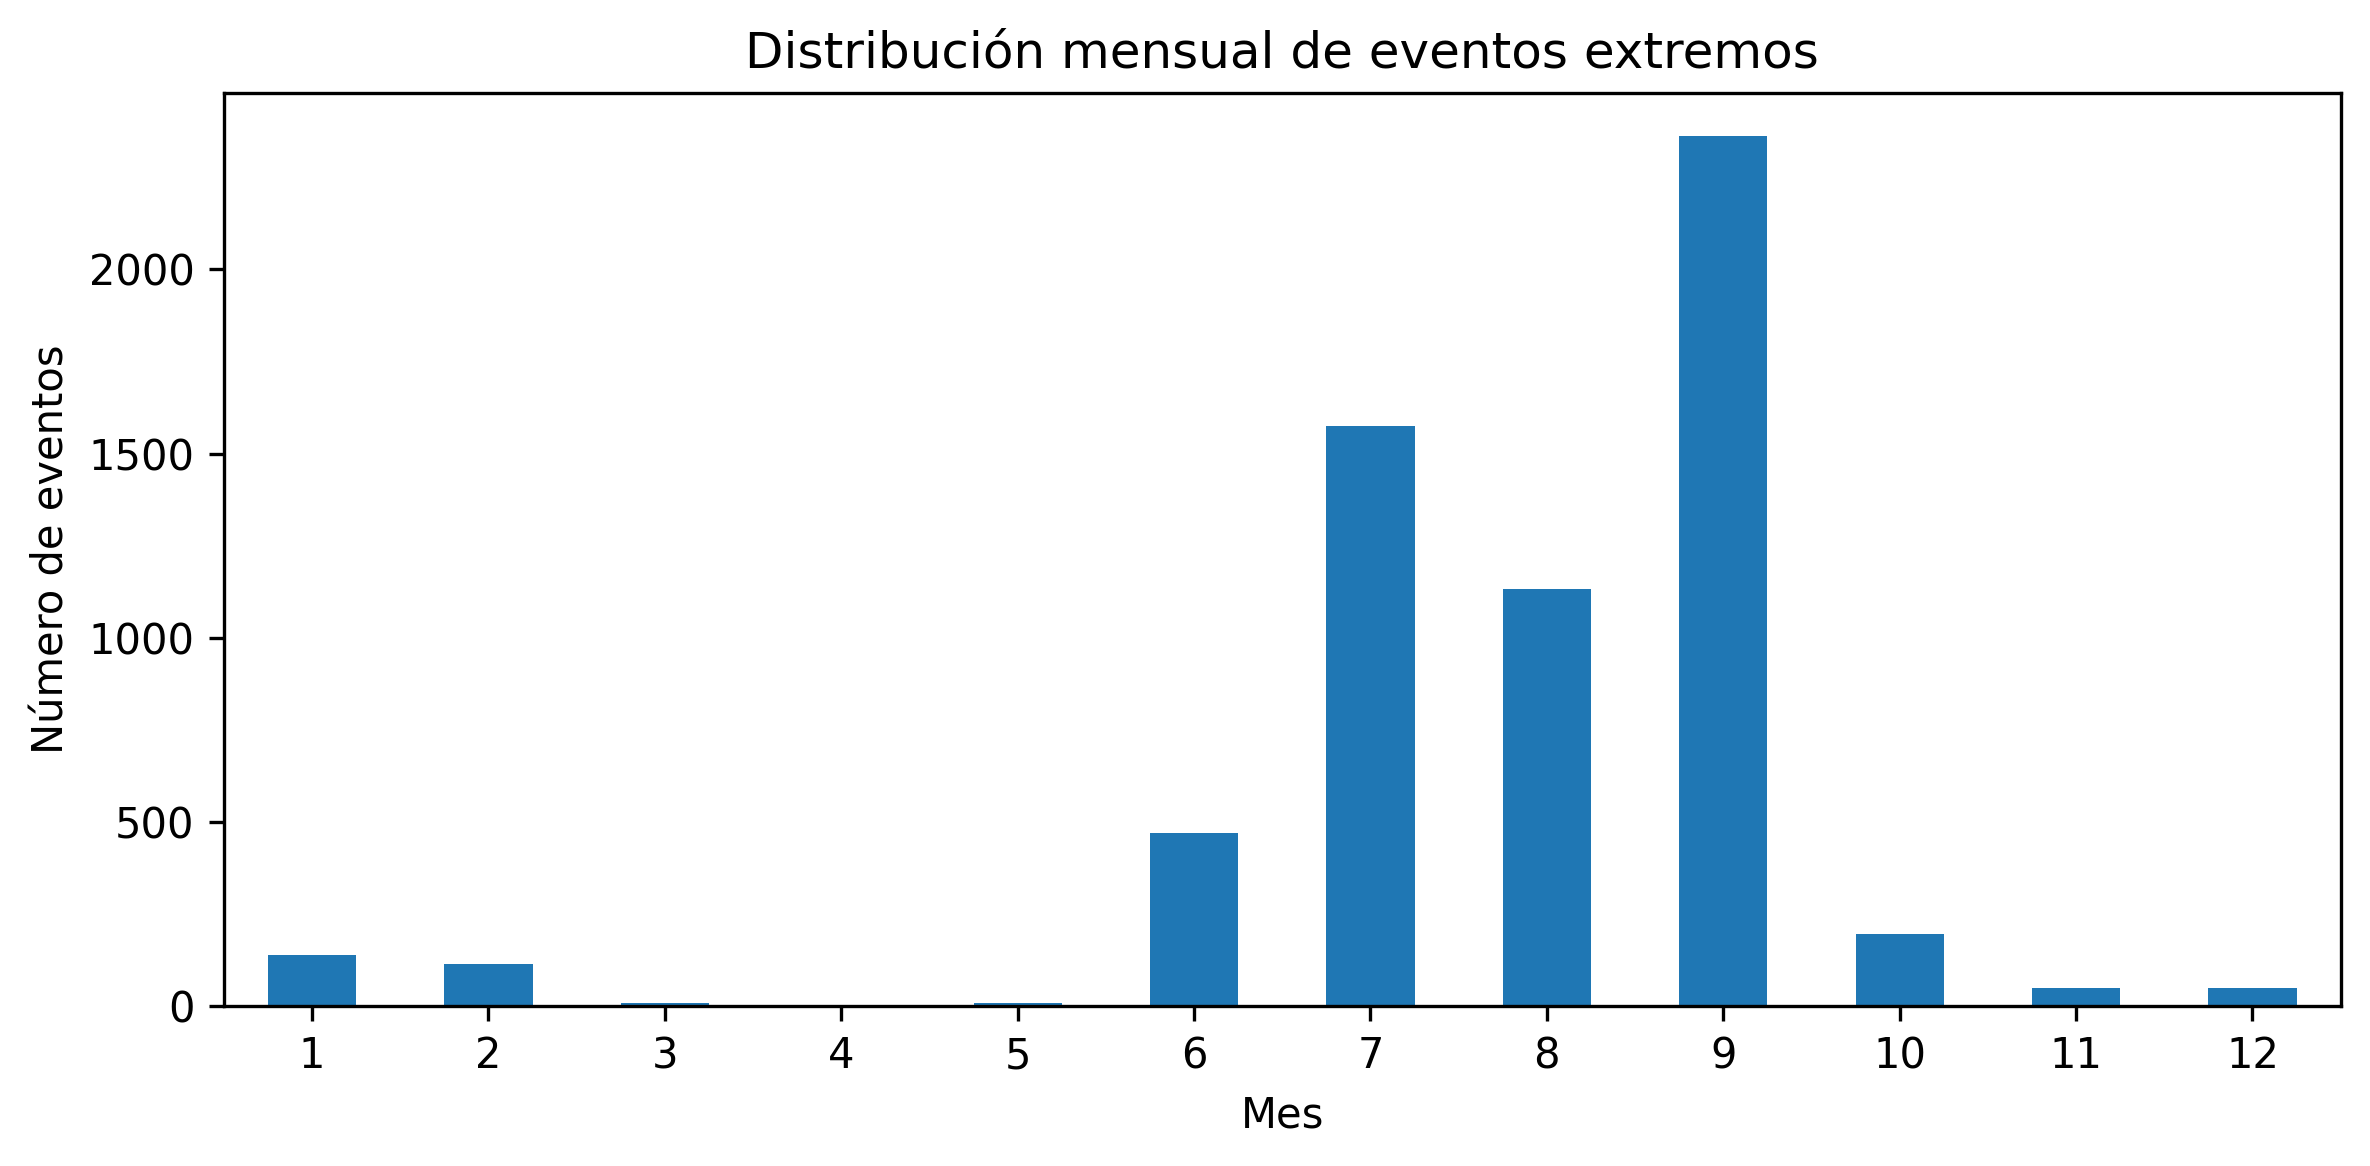

In [7]:
figuras_clave = [
    os.path.join(OUT_DIR, "heatmap_events_by_scenario.png"),
    os.path.join(OUT_DIR, "heatmap_events_by_type.png"),
    os.path.join(OUT_DIR, "events_by_station.png"),
    os.path.join(OUT_DIR, "events_by_month.png"),
]

for fp in figuras_clave:
    print("\nFigura:", os.path.basename(fp))
    print("Existe:", os.path.exists(fp))
    if os.path.exists(fp):
        display(Image(filename=fp))